# SUMMARIZING IMMUNE CELLS
## Sid Gurajala
## Last Updated: 03/21/2024

In [1]:
library(patchwork)
library(purrr)
library(dplyr) 
library(tidyr)
library(cowplot)
library(singlecellmethods)
library(ggplot2)
library(ggbeeswarm)
library(stringr)

source("/data/srlab/anathan/scripts/scseq_utils.R")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘singlecellmethods’


The following object is masked from ‘package:base’:

    rowMeans




In [2]:
labelfontsize = 20
tickfontsize = 16

figdir = '../../figures/components/'

In [3]:
source("/data/srlab/ssg34/SLE_kidney_v2/scripts/libs/kidney_utils_updated.r")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: viridisLite

Loading required package: Rcpp



In [4]:
# source("/data/srlab/ssg34/SLE_kidney_v2/scripts/libs/kidney_utils.r")
clinical <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/clinical_data_05042023.rds') %>% 
                        rename(Final_Site = Site) %>% select(-sample)

# Myeloid

In [5]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')
qcd_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_norm_10042022.rds')

In [5]:
wilcox <- wilcoxauc(qcd_norm, qcd_meta$new_cluster_number)

In [524]:
write.csv(wilcox, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_DEgenes_all_genes_05232023.csv')

In [6]:
wilcox <- rbind(wilcox %>% group_by(group) %>% slice_min(logFC, n = 20),
                wilcox %>% group_by(group) %>% slice_max(logFC, n = 20))

In [7]:
sn_control <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_control)
sn_LN <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_LN)
sc_control <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_control)
sc_LN <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_LN)
merged <- sc_LN %>% left_join(sc_control) %>% left_join(sn_LN) %>% left_join(sn_control)
merged[is.na(merged)] <- "0 (0)"

Joining with `by = join_by(new_cluster_number)`
Joining with `by = join_by(new_cluster_number)`
Joining with `by = join_by(new_cluster_number)`


In [36]:
write.csv(merged, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/myeloid_summary_04152024.csv', quote = FALSE, row.names = FALSE)

In [6]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')

In [5]:
percent_mito <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/percent_mito_from_rawcounts_12072023.rds')

In [10]:
qcd_meta <- left_join(qcd_meta, data.frame(new_cluster_number = seq(0, 20), 
                                           final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC')))
qcd_meta <- qcd_meta %>%  left_join(percent_mito)
saveRDS(qcd_meta, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')

Joining, by = "new_cluster_number"
Joining, by = c("cell", "percent.mt")


In [7]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')

## Fine Grain Cell Types Figure

### Single Cell UMAP, Single Nuclear UMAP

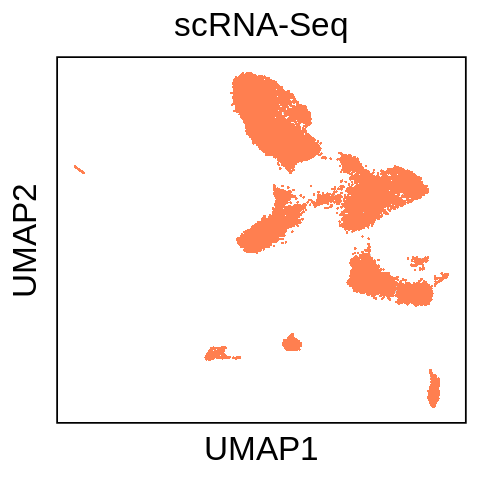

In [12]:
umap_plot = ggplot() +
  geom_point(
    data=select(qcd_meta, c(hUMAP1, hUMAP2, dataset)),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "lightgrey"
  ) + 
  geom_point(
    data=qcd_meta %>% filter(dataset == "scRNAseq") %>% select(hUMAP1, hUMAP2),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "coral"
  ) +
theme_classic(base_size = tickfontsize) +
  theme(
    legend.position = "none",
         plot.title = element_text(size = labelfontsize, hjust = 0.5),
          axis.title = element_text(size = labelfontsize), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          text=element_text(family="Arial")
  ) + labs(x = "UMAP1", y = "UMAP2", title = 'scRNA-Seq') 


outplot = umap_plot

height = 4
width = 4
fig.size(height, width)
outplot

ggsave(paste0(figdir, 'myeloid_umap_sc.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_umap_sc.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)


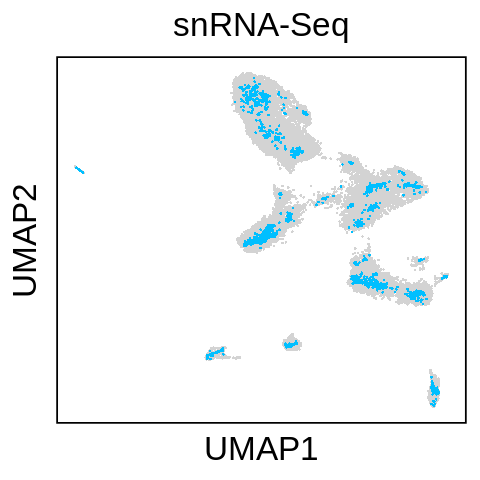

In [11]:
umap_plot = ggplot() +
  geom_point(
    data=select(qcd_meta, c(hUMAP1, hUMAP2, dataset)),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "lightgrey"
  ) + 
  geom_point(
    data=qcd_meta %>% filter(dataset == "snRNAseq") %>% select(hUMAP1, hUMAP2),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "deepskyblue"
  ) +
theme_classic(base_size = tickfontsize) +
  theme(
    legend.position = "none",
         plot.title = element_text(size = labelfontsize, hjust = 0.5),
          axis.title = element_text(size = labelfontsize), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          text=element_text(family="Arial")
  ) + labs(x = "UMAP1", y = "UMAP2", title = 'snRNA-Seq') 


outplot = umap_plot

height = 4
width = 4
fig.size(height, width)
outplot

ggsave(paste0(figdir, 'myeloid_umap_sn.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_umap_sn.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

### Cluster UMAPs

In [4]:
qcd_meta <- left_join(qcd_meta, data.frame(new_cluster_number = seq(0, 20), 
                                           final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC')))

Joining, by = "new_cluster_number"


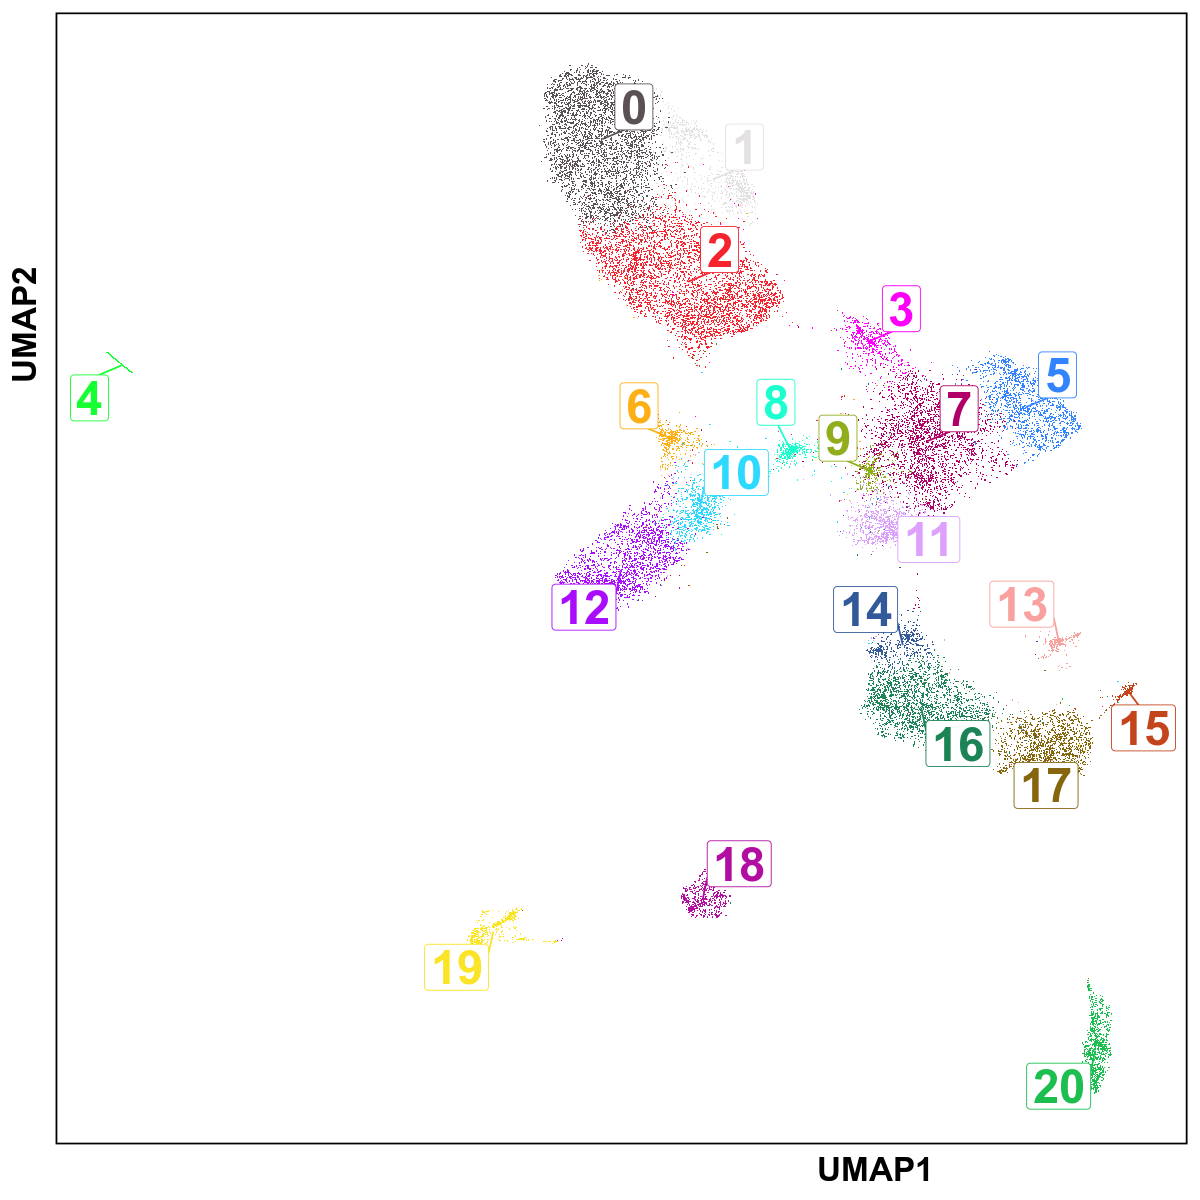

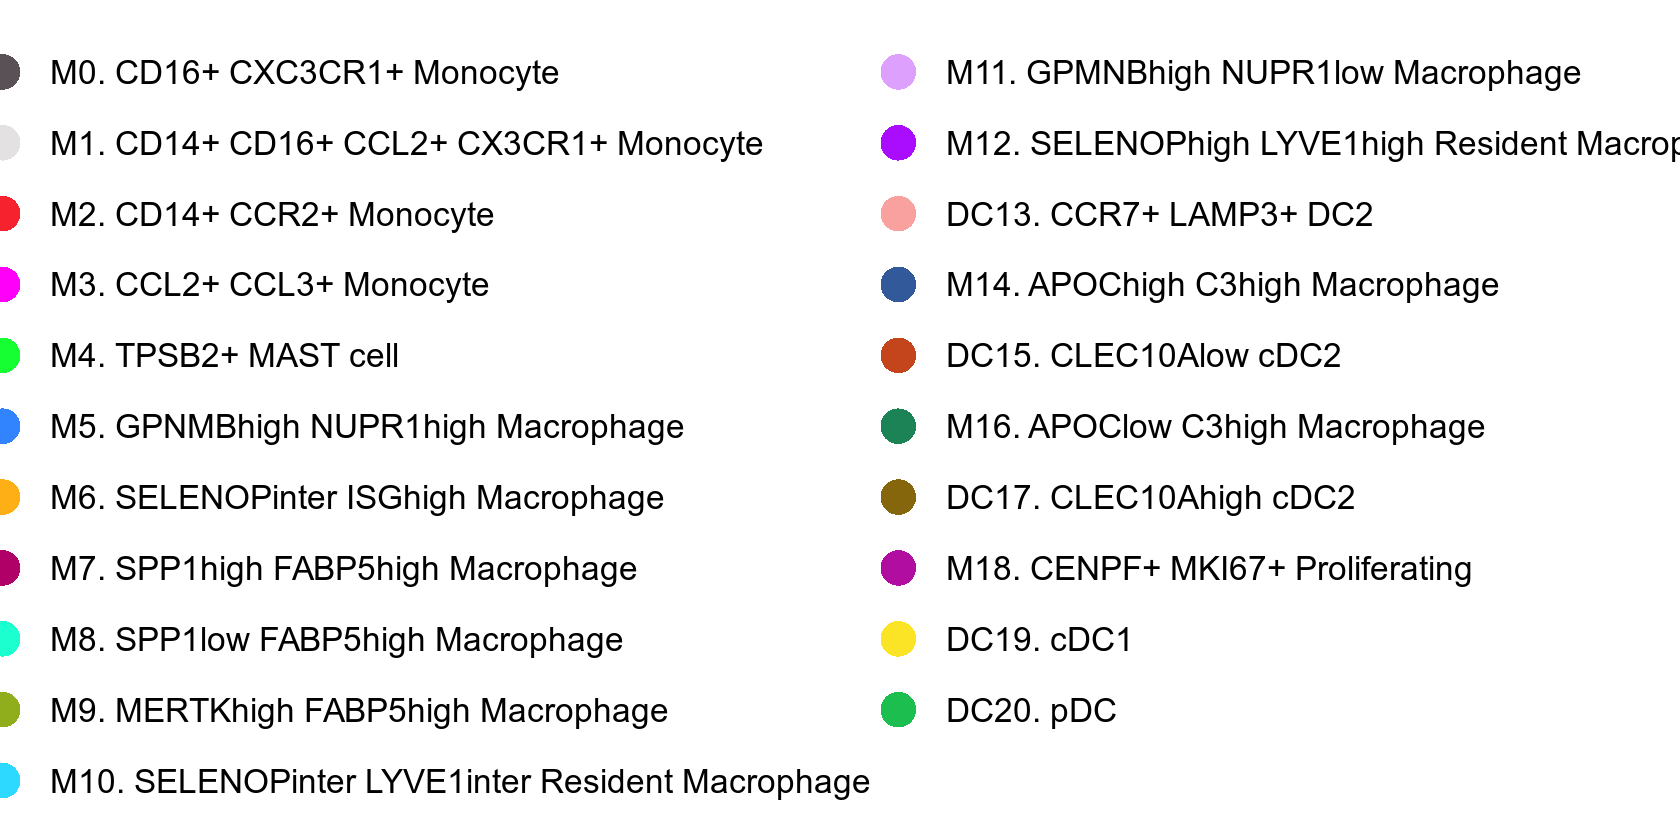

In [10]:
options(warn=-1)
cluster_center <- qcd_meta %>%
                  group_by(new_cluster_number, final_annotation) %>%
                  summarise_at(vars(hUMAP1, hUMAP2), funs(median(., na.rm=TRUE)))
cluster_center <- as.data.frame(cluster_center)

options(repr.plot.height = 9, repr.plot.width = 18)
p <- ggplot() +
      geom_point(
        data = qcd_meta[sample(nrow(qcd_meta)), ] %>% 
          select(hUMAP1, hUMAP2, new_cluster_number, final_annotation) %>% 
                  mutate(final_annotation = factor(final_annotation, 
                                                   levels = cluster_center$final_annotation)),
        aes(x = hUMAP1, y = hUMAP2, color = final_annotation),
          size = 0.6, shape = 20, stroke = 0.0001) +
      ggrepel::geom_label_repel(
        data = cluster_center,
        aes(x = hUMAP1, y = hUMAP2, 
            label = new_cluster_number, color = as.factor(final_annotation)),
        size = 10,  fontface = "bold",
        box.padding = unit(0.5, "lines"),
        point.padding = unit(0.01, "lines"),
        show.legend = FALSE
      ) +
        scale_color_manual(values =as.vector(polychrome(26))) +
    theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1),
              legend.text = element_text(size = 20),
              legend.title = element_blank()
          
    ) +
    theme(text=element_text(family="Arial")) + 
        labs(x = "UMAP1", y = "UMAP2") +
        guides(color = guide_legend(ncol = 2, override.aes = list(size = 15)))
legend <- cowplot::get_legend(p)
p <- p + theme(legend.position = "none")
legend <- cowplot::plot_grid(legend)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/figure2/figure2c.png",
       p,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/figure2/figure2c-legend.png",
       legend,
       base_height = 7,
       base_width = 15)
fig.size(10, 10)
p
fig.size(7, 14)
legend
options(warn=0)

### Marker Gene UMAPs

In [13]:
markers = c('CD14', 'FCGR3A', 'MSR1', 'C1QA')

In [14]:
qcd_scaled = qcd_norm[markers, ] %>% scaleData
vmax = qcd_scaled %>% quantile(.95)
vmin = qcd_scaled %>% quantile(.05)

In [15]:
p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[1], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p1 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[2], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p2 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[3], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p3 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[4], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p4 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

umap_legend = get_legend(p +theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
                theme(text=element_text(family="Arial"))))
umap_legend = cowplot::plot_grid(umap_legend) 

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


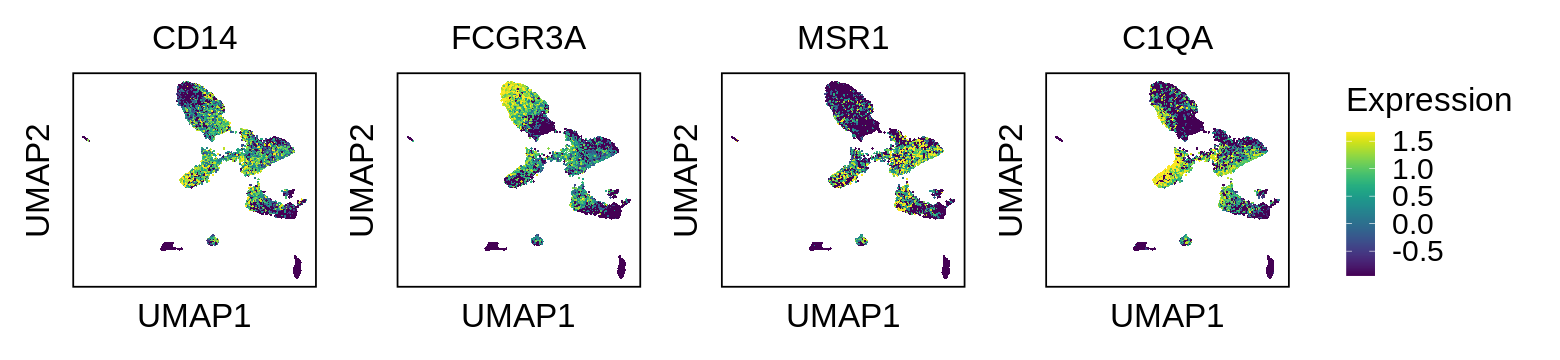

In [17]:
height = 3
width = 13
fig.size(height, width)

outplot = p1 + p2 + p3 + p4 + umap_legend + plot_layout(nrow = 1)
outplot

ggsave(paste0(figdir, 'myeloid_umap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_umap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

### Gene Heatmaps

In [8]:
qcd_meta <- left_join(qcd_meta, data.frame(new_cluster_number = seq(0, 20), 
                                           final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC')))

Joining with `by = join_by(new_cluster_number, final_annotation)`


In [9]:
final_annotation <- data.frame(new_cluster_number = seq(0, 20), 
                                           final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC'))

In [10]:
marker.genes <- c("CD14", "FCGR3A", "CCR2", 'CCL2', "TPSB2",  "APOC1", "NUPR1",
                  "SPP1", "GPNMB", 
                  "TIMP1", "FABP5", "C1QA", "SELENOP", "LYVE1", "CCR7", "LAMP3", 
                  "C3", 'HLA-DRB1', "CD1C", "FCER1A", 
                  "CENPF", "MKI67", "CADM1", "CLEC9A", 
                  "JCHAIN", "TCF4")

In [11]:
annotation.order = c('M0. CD16+ CXC3CR1+ Monocyte', 
                       'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                       'M2. CD14+ CCR2+ Monocyte',
                       'M3. CCL2+ CCL3+ Monocyte',
                       'M4. TPSB2+ MAST cell',
                       'M5. GPNMBhigh NUPR1high Macrophage',
                       'M6. SELENOPinter ISGhigh Macrophage', 
                       'M7. SPP1high FABP5high Macrophage',
                       'M8. SPP1low FABP5high Macrophage',
                       'M9. MERTKhigh FABP5high Macrophage',
                       'M10. SELENOPinter LYVE1inter Resident Macrophage',
                       'M11. GPMNBhigh NUPR1low Macrophage',
                       'M12. SELENOPhigh LYVE1high Resident Macrophage',
                       'DC13. CCR7+ LAMP3+ DC2', 
                       'M14. APOChigh C3high Macrophage',
                       'DC15. CLEC10Alow cDC2',
                       'M16. APOClow C3high Macrophage',
                       'DC17. CLEC10Ahigh cDC2',
                       'M18. CENPF+ MKI67+ Proliferating',
                       'DC19. cDC1',
                       'DC20. pDC')

In [12]:
library(googlesheets4)
gs4_deauth()

tissue_names = read_sheet("https://docs.google.com/spreadsheets/d/1f94hwyuDMvSUQyelWM89xfhDos7izNQw9bQ4amml2OQ/edit?usp=sharing", 
                 sheet = "Tissue")
tissue_names = setNames(tissue_names$Annotation_latest, tissue_names$Annotation_v1)
qcd_meta = qcd_meta %>% mutate(final_annotation = recode(final_annotation, !!!tissue_names))

annotation.order = recode(annotation.order, !!!tissue_names)

✔ Reading from UpdatedClusterNames.

✔ Range ''Tissue''.



In [13]:
marker_genes = marker.genes

In [14]:
wilcox_sn <- wilcoxauc(qcd_norm[, qcd_meta %>% filter(dataset == 'snRNAseq') %>% pull(cell)], 
                       qcd_meta %>% filter(dataset == 'snRNAseq') %>% pull(final_annotation))
wilcox_sc <- wilcoxauc(qcd_norm[, qcd_meta %>% filter(dataset == 'scRNAseq') %>% pull(cell)], 
                       qcd_meta %>% filter(dataset == 'scRNAseq') %>% pull(final_annotation))

In [15]:
sc_plot_df <- wilcox_sc %>%  filter(feature %in% marker_genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 
sn_plot_df <- wilcox_sn %>%  filter(feature %in% marker_genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 

In [16]:
setdiff(sc_plot_df$group, annotation.order)

character(0)

In [17]:
title = 'scRNA-seq'
dat_all = sc_plot_df %>% rename(percent = pct_in, zscore = avgExpr_scaled) 

dat = dat_all %>% pivot_wider(id_cols = 'feature', names_from = 'group', 
                    values_from = 'zscore') %>% as.data.frame
rownames(dat) = dat$feature
dat = dat %>% select(-feature)
row.order = marker_genes
col.order = annotation.order
# row.order = rownames(dat)[hclust(dist(dat))$order]
# col.order = colnames(dat)[hclust(dist(t(dat)))$order]
dat = dat_all
dat$group = factor(dat$group, levels = col.order)
dat$feature = factor(dat$feature, levels = row.order)

# dat = dat[!is.na(dat$group), ]

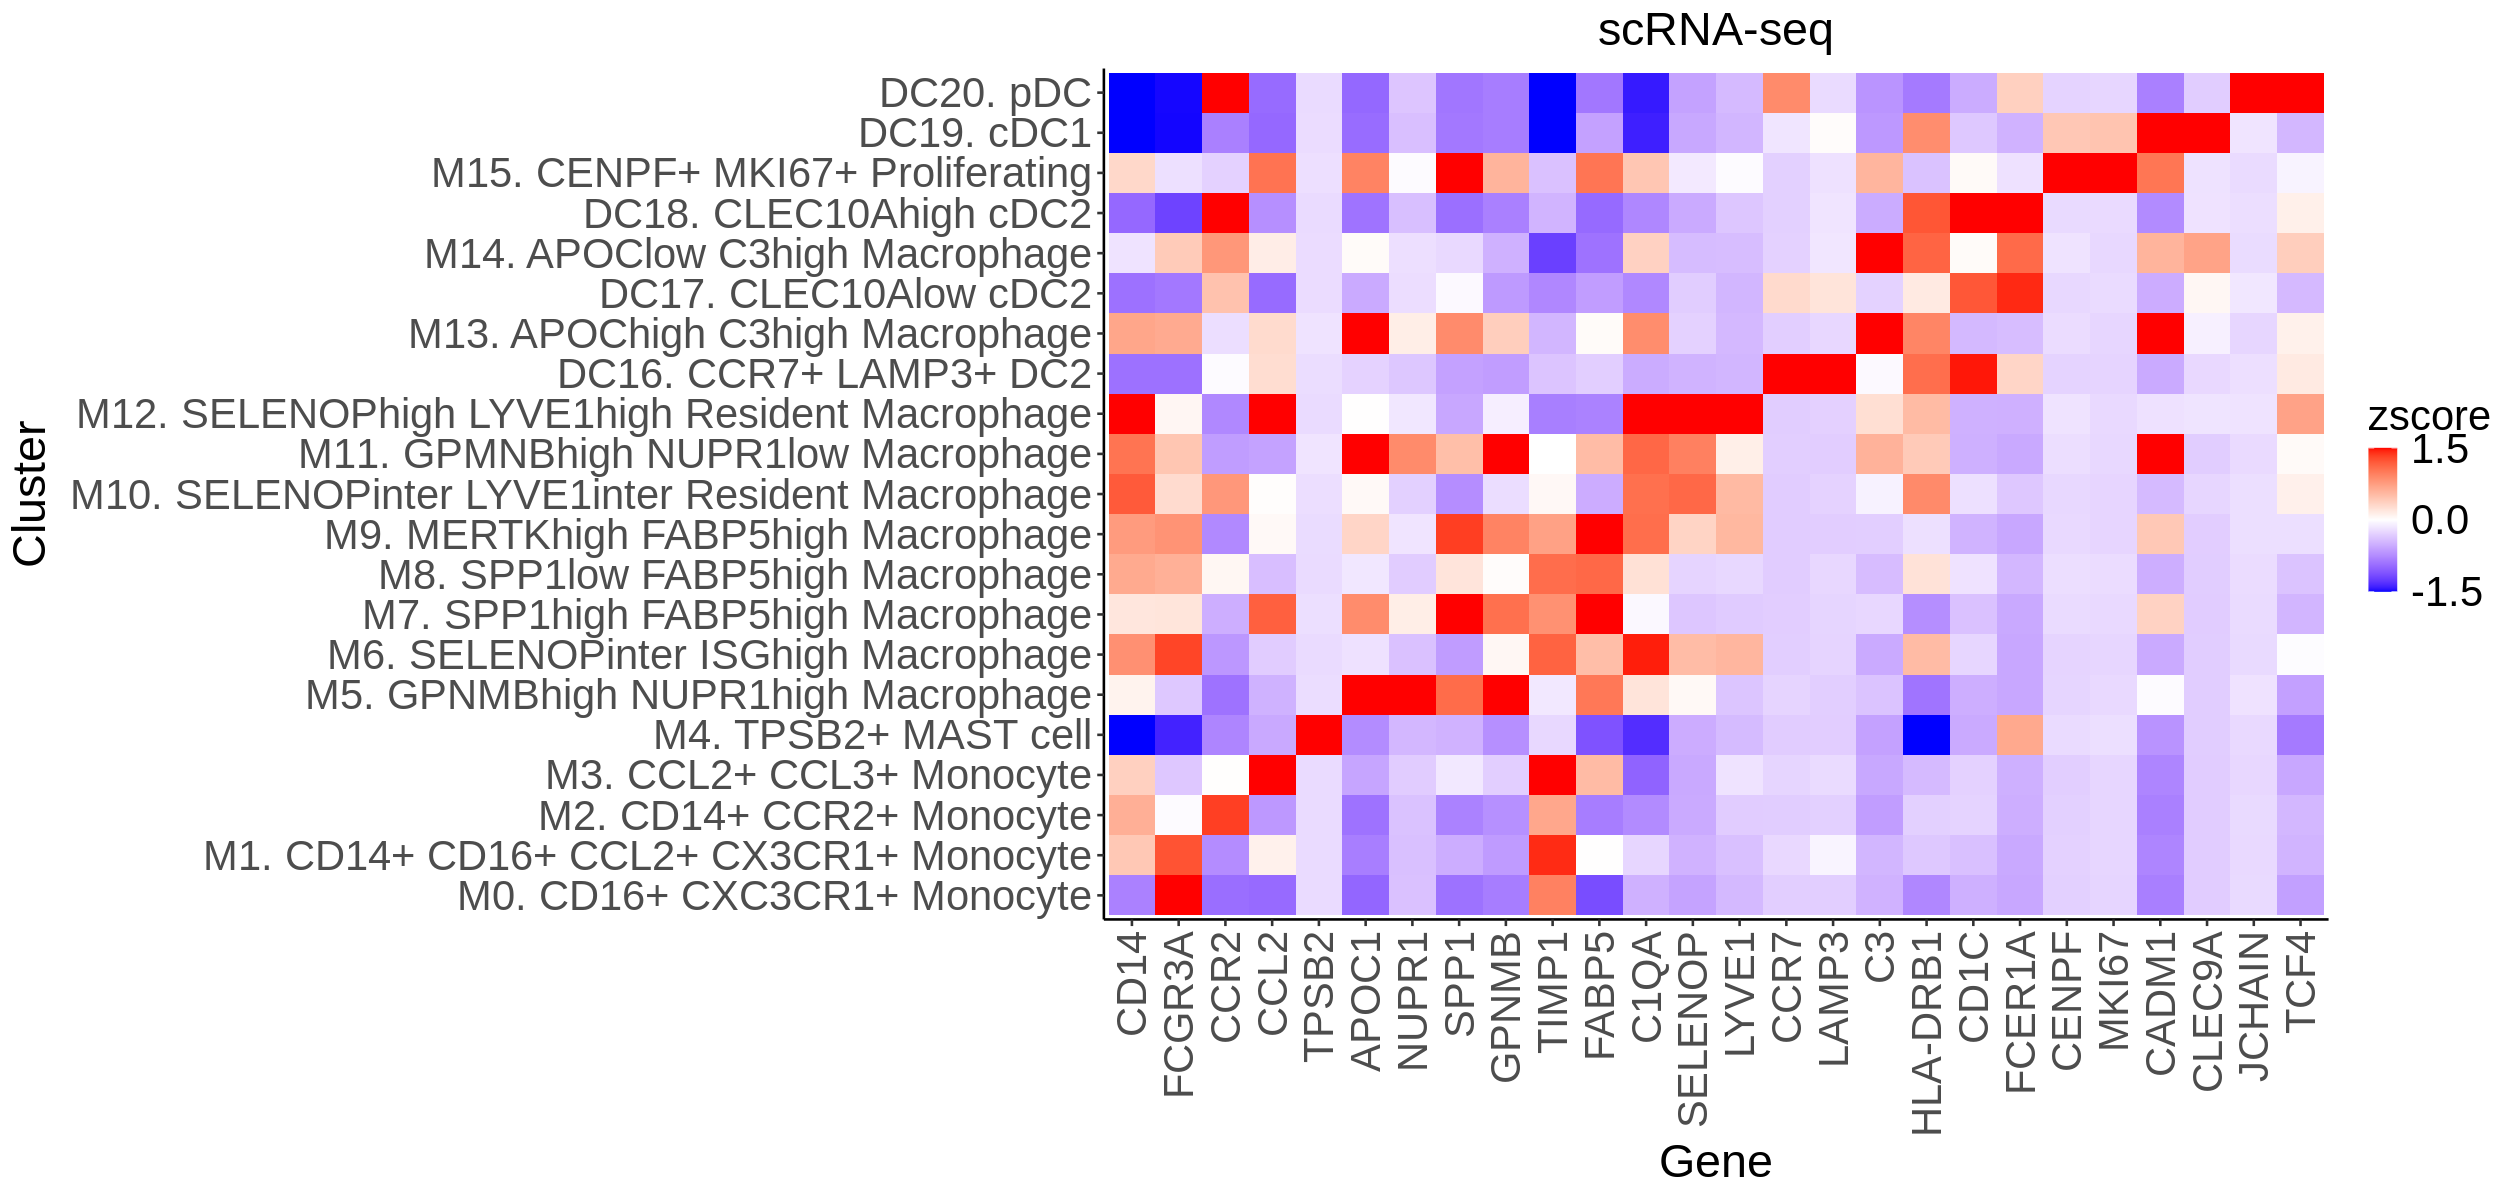

In [19]:
height = 10
width = 21
fig.size(height, width)


marker_heatmap = ggplot(dat, 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = tickfontsize) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish, breaks = c(-1.5, 0, 1.5)) + 
    # scale_x_discrete(limits = marker_genes) + 
    # scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = .5),
          axis.text = element_text( size = labelfontsize+5),
          axis.title = element_text(size = labelfontsize+8), 
          plot.title = element_text(size = labelfontsize+8, hjust = 0.5), 
          legend.text = element_text(size = labelfontsize+5),
          legend.title = element_text(size = labelfontsize+5)

         ) + 
    labs(x = "Gene", y = "Cluster", title = title)

outplot = marker_heatmap
outplot

ggsave(paste0(figdir, 'myeloid_sc_heatmap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_sc_heatmap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [31]:
title = 'snRNA-seq'
dat_all = sn_plot_df %>% rename(percent = pct_in, zscore = avgExpr_scaled) 

# dat = dat_all %>% pivot_wider(id_cols = 'feature', names_from = 'group', 
#                     values_from = 'zscore') %>% as.data.frame
# rownames(dat) = dat$feature
# dat = dat %>% select(-feature)
# row.order = rownames(dat)[hclust(dist(dat))$order]
# col.order = colnames(dat)[hclust(dist(t(dat)))$order]
dat = dat_all
dat$group = factor(dat$group, levels = col.order)
dat$feature = factor(dat$feature, levels = row.order)
# dat = dat[!is.na(dat$group), ]

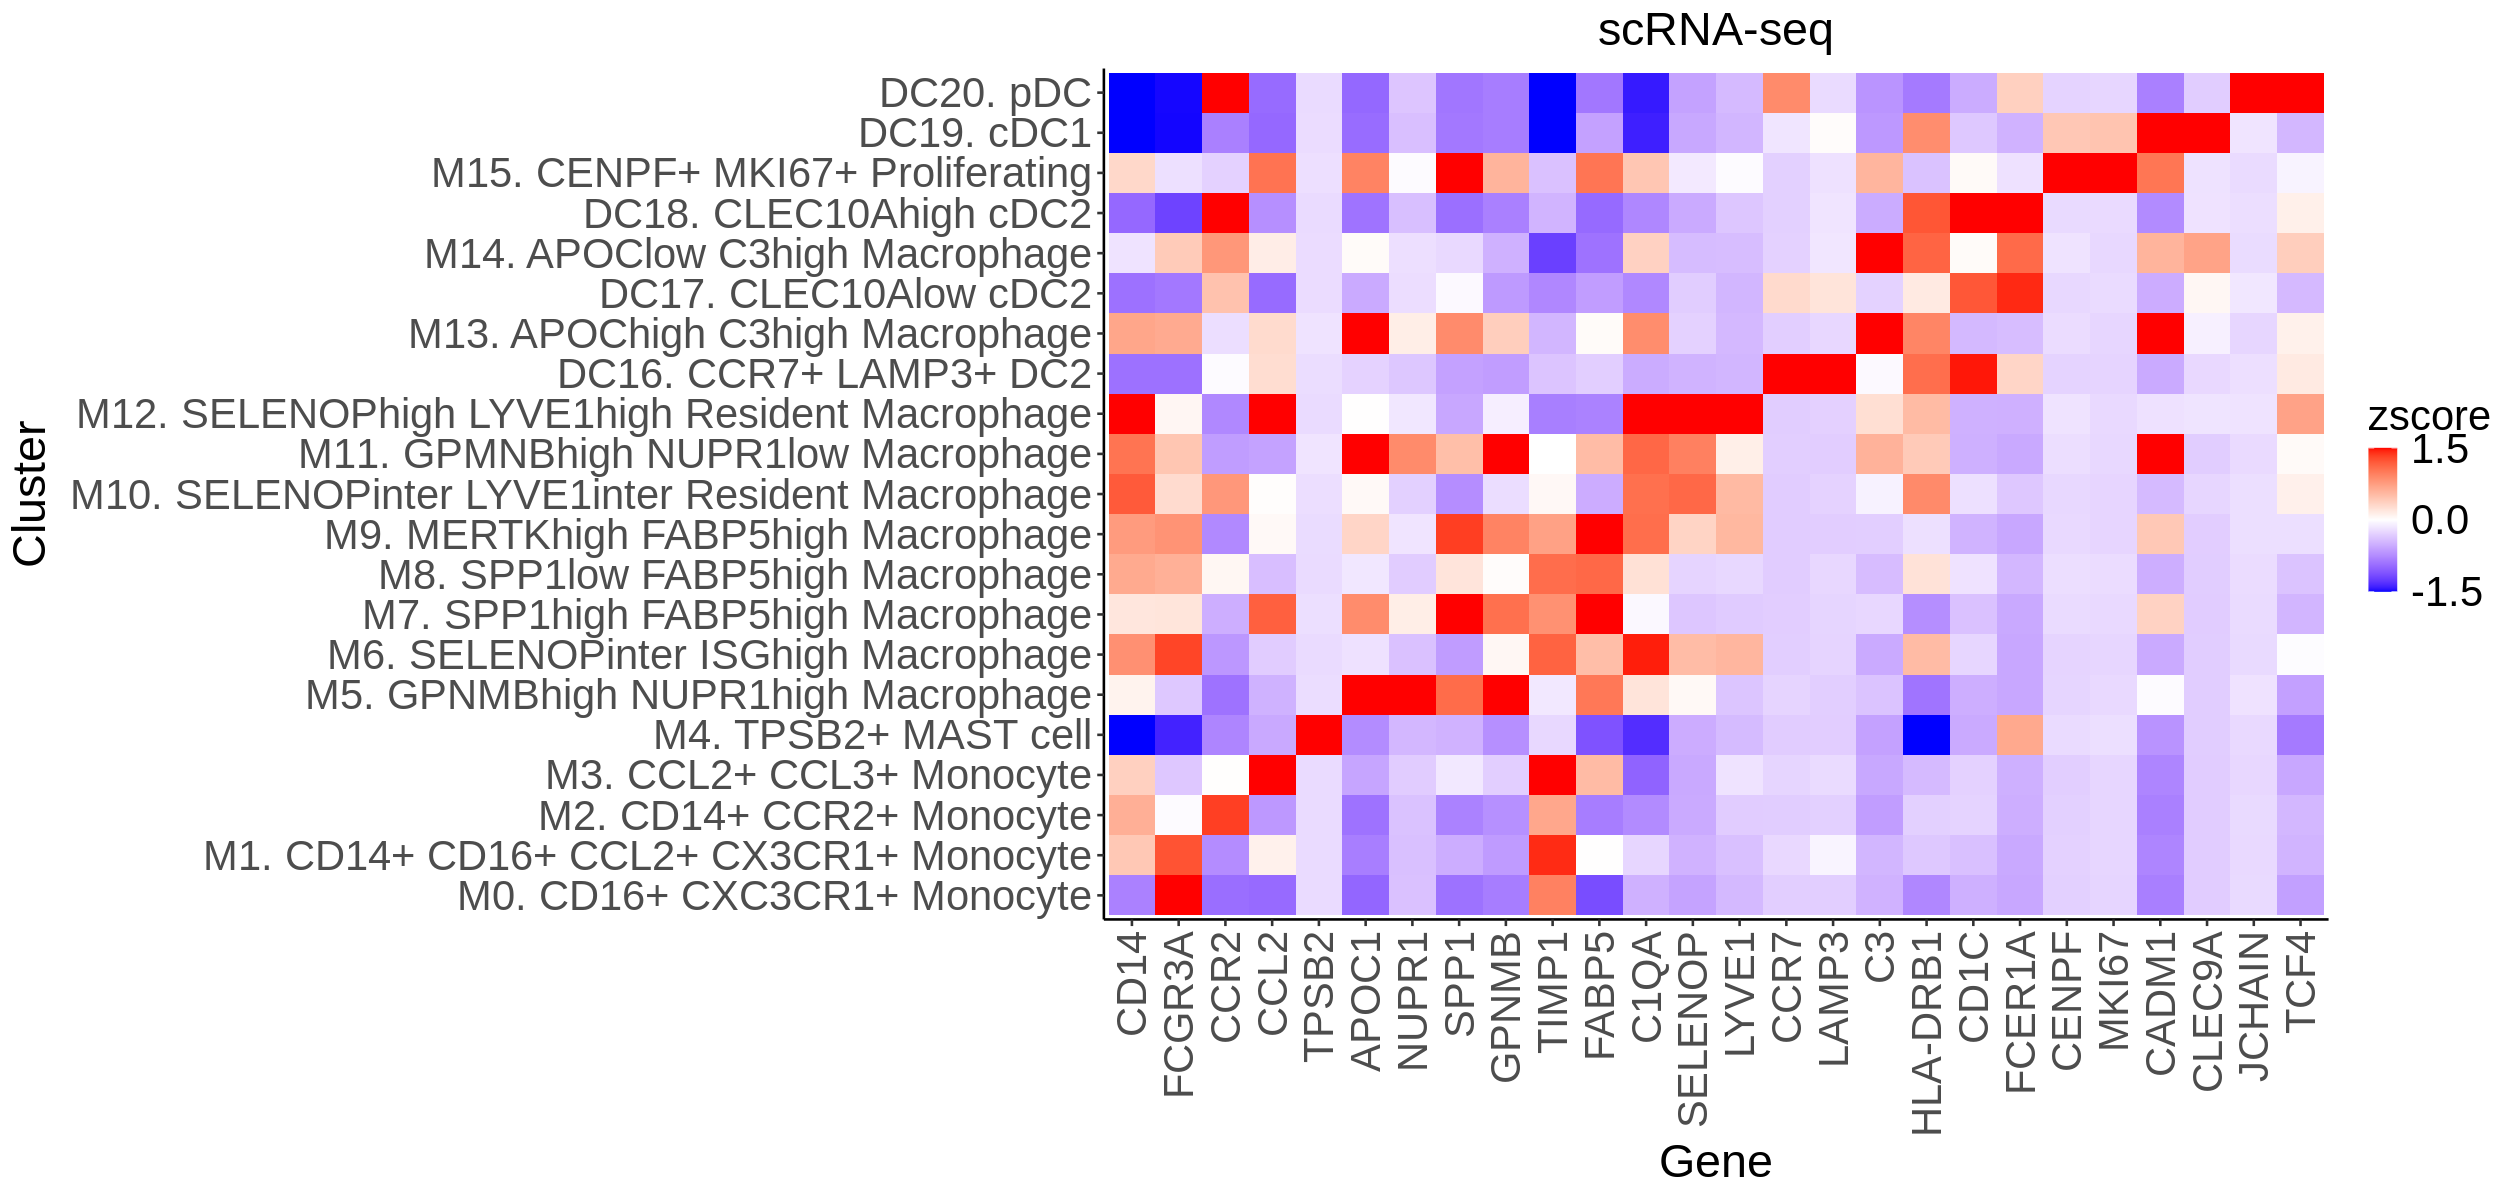

In [20]:
height = 10
width = 21
fig.size(height, width)


marker_heatmap = ggplot(dat, 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = tickfontsize) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish, breaks = c(-1.5, 0, 1.5)) + 
    # scale_x_discrete(limits = marker_genes) + 
    # scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = .5),
          axis.text = element_text( size = labelfontsize+5),
          axis.title = element_text(size = labelfontsize+8), 
          plot.title = element_text(size = labelfontsize+8, hjust = 0.5), 
          legend.text = element_text(size = labelfontsize+5),
          legend.title = element_text(size = labelfontsize+5)

         ) + 
    labs(x = "Gene", y = "Cluster", title = title)

outplot = marker_heatmap
outplot

ggsave(paste0(figdir, 'myeloid_sn_heatmap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_sn_heatmap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

### Cluster Proportions in Matched Patients

In [34]:
qcd_meta <- qcd_meta  %>% 
                mutate(individual = str_split(sample, '_')) %>% 
                rowwise() %>% 
                mutate(individual = unlist(individual)[3]) 

In [35]:
sample_freq <- qcd_meta %>% select(dataset, individual, new_cluster_number) %>% 
                    table() %>% data.frame() %>% 
                    pivot_wider(names_from = "new_cluster_number", values_from = Freq) 

In [36]:
ind_list <- qcd_meta %>% select(dataset, individual) %>% 
                table() %>% data.frame() %>% 
                pivot_wider(names_from = 'dataset', values_from = "Freq") %>% filter(scRNAseq > 30 & snRNAseq > 30) %>% 
                pull(individual)

In [37]:
sample_freq_sc <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "scRNAseq") %>% 
                    select(-dataset) %>% colSums()

sample_freq_sn <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "snRNAseq") %>% 
                    select(-dataset) %>% colSums()

In [38]:
sample_freq <- data.frame(rep("a", 21))
sample_freq$sc_freq <- sample_freq_sc / sum(sample_freq_sc)
sample_freq$sc_se <- sqrt((sample_freq$sc_freq * (1 - sample_freq$sc_freq)) / sample_freq_sc)
sample_freq$sn_freq <- sample_freq_sn / sum(sample_freq_sn)
sample_freq$sn_se <- sqrt((sample_freq$sn_freq * (1 - sample_freq$sn_freq)) / sample_freq_sn)
sample_freq <- sample_freq[,- 1]
sample_freq$new_cluster_number <- as.character(seq(0, 20))

In [39]:
r = cor(sample_freq$sc_freq, sample_freq$sn_freq)
pval = cor.test(sample_freq$sc_freq, sample_freq$sn_freq)$p.value

In [40]:
format(pval, format = 'e', digits = 3)

[1] "0.00173"

In [42]:
title = 'Myeloid'

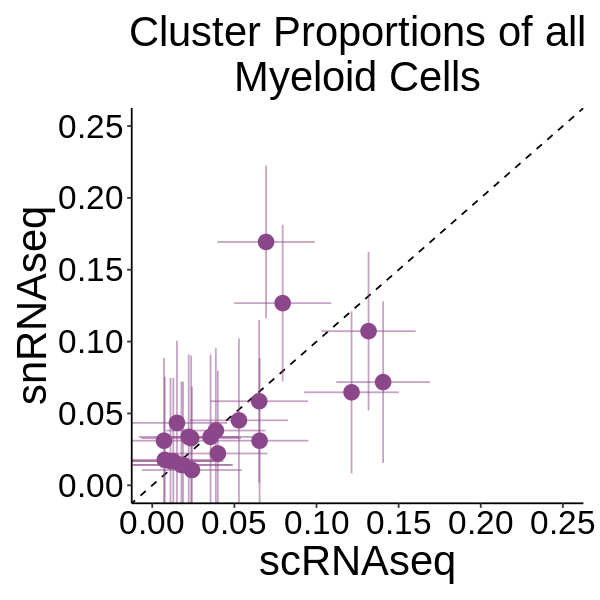

In [45]:
max_val <- max(sample_freq[, c("sc_freq", "sn_freq")])

p = ggplot(sample_freq, aes(x = sc_freq, y = sn_freq)) + 
    geom_abline(linetype = "dashed") +
    # scale_color_manual(values =as.vector(rev(palette36.colors(26)))) +
    theme_classic() + 
    geom_linerange(aes(ymax = sn_freq+1.96*sn_se, 
                        ymin = sn_freq-1.96*sn_se), alpha = 0.5, color = 'orchid4') +
    geom_linerange(aes(xmax = sc_freq+1.96*sc_se, 
                        xmin = sc_freq-1.96*sc_se), alpha = 0.5, color = 'orchid4') +
    geom_point(size = 4, color = 'orchid4') + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18)) +
    coord_cartesian(xlim = c(0, 0.25), ylim = c(0, 0.25)) + 
    labs(x = "scRNAseq",
         y = "snRNAseq", title = paste0('Cluster Proportions of all\n', title, ' Cells'))+
    annotate("text", x = 0, y = 0.4, label = paste0('R=', round(r, 2)), hjust =0, 
         size =7)+
    annotate("text", x = 0, y = 0.36, label = paste0('P=', 
             format(pval, format = 'e', digits = 3)), hjust =0, 
         size =7)

p = p +theme(axis.text = element_text(color = "black", size = labelfontsize, vjust = 0.5),
           axis.title = element_text(size=labelfontsize+5, hjust = 0.5),
            legend.text = element_text(size = labelfontsize),
            legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize+5),
                theme(text=element_text(family="Arial")),
                                    plot.margin = margin(10, 10, 10, 10))
height = 5
width = 5
fig.size(height, width)

outplot = p
outplot

ggsave(paste0(figdir, 'myeloid_scsn_cellfreqcorr.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_scsn_cellfreqcorr.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [44]:
cor.test(sample_freq$sc_freq, sample_freq$sn_freq)


	Pearson's product-moment correlation

data:  sample_freq$sc_freq and sample_freq$sn_freq
t = 3.6424, df = 19, p-value = 0.001733
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2897336 0.8403053
sample estimates:
      cor 
0.6412203 


### sc/sn qq ratio

In [316]:
#find individual from sample
qcd_meta <- qcd_meta %>% 
                        mutate(individual = str_split(sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3])
#filter for individuals with > X cells 
ind_meta <- qcd_meta %>% 
                    select(individual, dataset) %>% 
                    table() %>% data.frame() 

ind_keep <- vector() 

for (i in unique(ind_meta$individual)) {
    ind_subset <- ind_meta %>% filter(individual == i)
        if (all(ind_subset$Freq > 10)) {
            ind_keep <- c(ind_keep, i)
        }
}

#pseudobulking
qq_pb_sc <- data.frame(nrow = nrow(all_immune_norm))
individuals_sc <- vector()

for (i in ind_keep) {
            subset <- qcd_meta %>% filter(individual == i, 
                                                 dataset == "scRNAseq") %>% 
                        pull(cell)
            pb_vec <- rowMeans(qcd_norm[, subset])
            qq_pb_sc <- cbind(qq_pb_sc, pb_vec)
            individuals_sc <- c(individuals_sc, i)
}

qq_pb_sn <- data.frame(nrow = nrow(all_immune_norm))
individuals_sn <- vector()

for (i in ind_keep) {
    subset <- qcd_meta %>% filter(individual == i, 
                                                 dataset == "snRNAseq") %>% 
                        pull(cell)
            pb_vec <- rowMeans(qcd_norm[, subset])
            qq_pb_sn <- cbind(qq_pb_sn, pb_vec)
            individuals_sn <- c(individuals_sn, i)
}

#remove extraneous first column
qq_pb_sc <- qq_pb_sc[, -1]
qq_pb_sn <- qq_pb_sn[, -1]

#assign column names
colnames(qq_pb_sc) <- paste0(individuals_sc, "_sc")
colnames(qq_pb_sn) <- paste0(individuals_sn, "_sn")
qq_pb <- cbind(qq_pb_sc, qq_pb_sn)

#qqnormalization 
index_to_mean <- function(my_index, my_mean){
  return(my_mean[my_index])
}
df_rank <- apply(qq_pb,2,rank,ties.method="first")
df_sort <- data.frame(apply(df, 2, sort))
df_mean <- apply(df_sort, 1, mean)
df_final <- apply(df_rank, 2, index_to_mean, my_mean=df_mean)

#transpose to df
df_final <- t(df_final) %>% data.frame()

#assign covariates from rownames
df_final <- df_final %>% mutate(ind = sapply(rownames(df_final), 
                                             FUN = function(x) unlist(str_split(x, "_"))[1]),
                                technology = sapply(rownames(df_final), 
                                                    FUN = function(x) unlist(str_split(x, "_"))[2]))

#run pb linear model
out_myeloid <- data.frame()
for (i in 1:nrow(qcd_norm)) {
    gene = rownames(qcd_norm)[i]
    model_df <- cbind(df_final[, i], df_final %>% select(ind, technology))
    colnames(model_df) <- c('Exp', 'ind', 'technology')
    H0 <- lm(Exp ~ ind, data = model_df)
    H1 <- lm(Exp ~ ind + technology, data = model_df)

    ANNO <- anova(H0, H1)
    LRP <- ANNO[2,6]
    F <- ANNO[2,5]
    Beta <- summary(H1)$coefficients['technologysn', 'Estimate']
    SE <- summary(H1)$coefficients['technologysn', 'Std. Error']
    res <- c(gene = gene, LRP = LRP, F = F, Beta = Beta, SE = SE)
    out_myeloid <- rbind(out_myeloid, res)
}

#format output 
colnames(out_myeloid) <- c('gene', 'LRP', 'F', 'Beta', 'SE')
out_myeloid[out_myeloid == "NaN"] <- NA

In [322]:
out_filter <- out_myeloid %>% na.omit() %>% 
                mutate(LRP = as.numeric(LRP),
                       F = as.numeric(F),
                       Beta = as.numeric(Beta),
                       SE = as.numeric(SE)) %>% 
                mutate(FDR = p.adjust(LRP, method = "BH")) %>% 
                filter(FDR < 0.05)

In [323]:
library(msigdbr)
library(fgsea)

##format for gsea 
FC.vec <- out_filter$Beta
names(FC.vec) <- out_filter$gene

scoreType <- "std"

H <- msigdbr(species = "Homo sapiens", category = "H")

H.ensembl.ls <- H %>% 
  select(gs_name, gene_symbol) %>% 
  group_by(gs_name) %>% 
  summarise(all.genes = list(unique(gene_symbol))) %>% 
  tibble::deframe()

#Run GSEA
gsea.H <- fgseaSimple(pathways = H.ensembl.ls,
                      stats = FC.vec,
                      scoreType = scoreType,
                      nperm=10000)

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.37% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


Warning message:
“Removed 15487 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 602 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


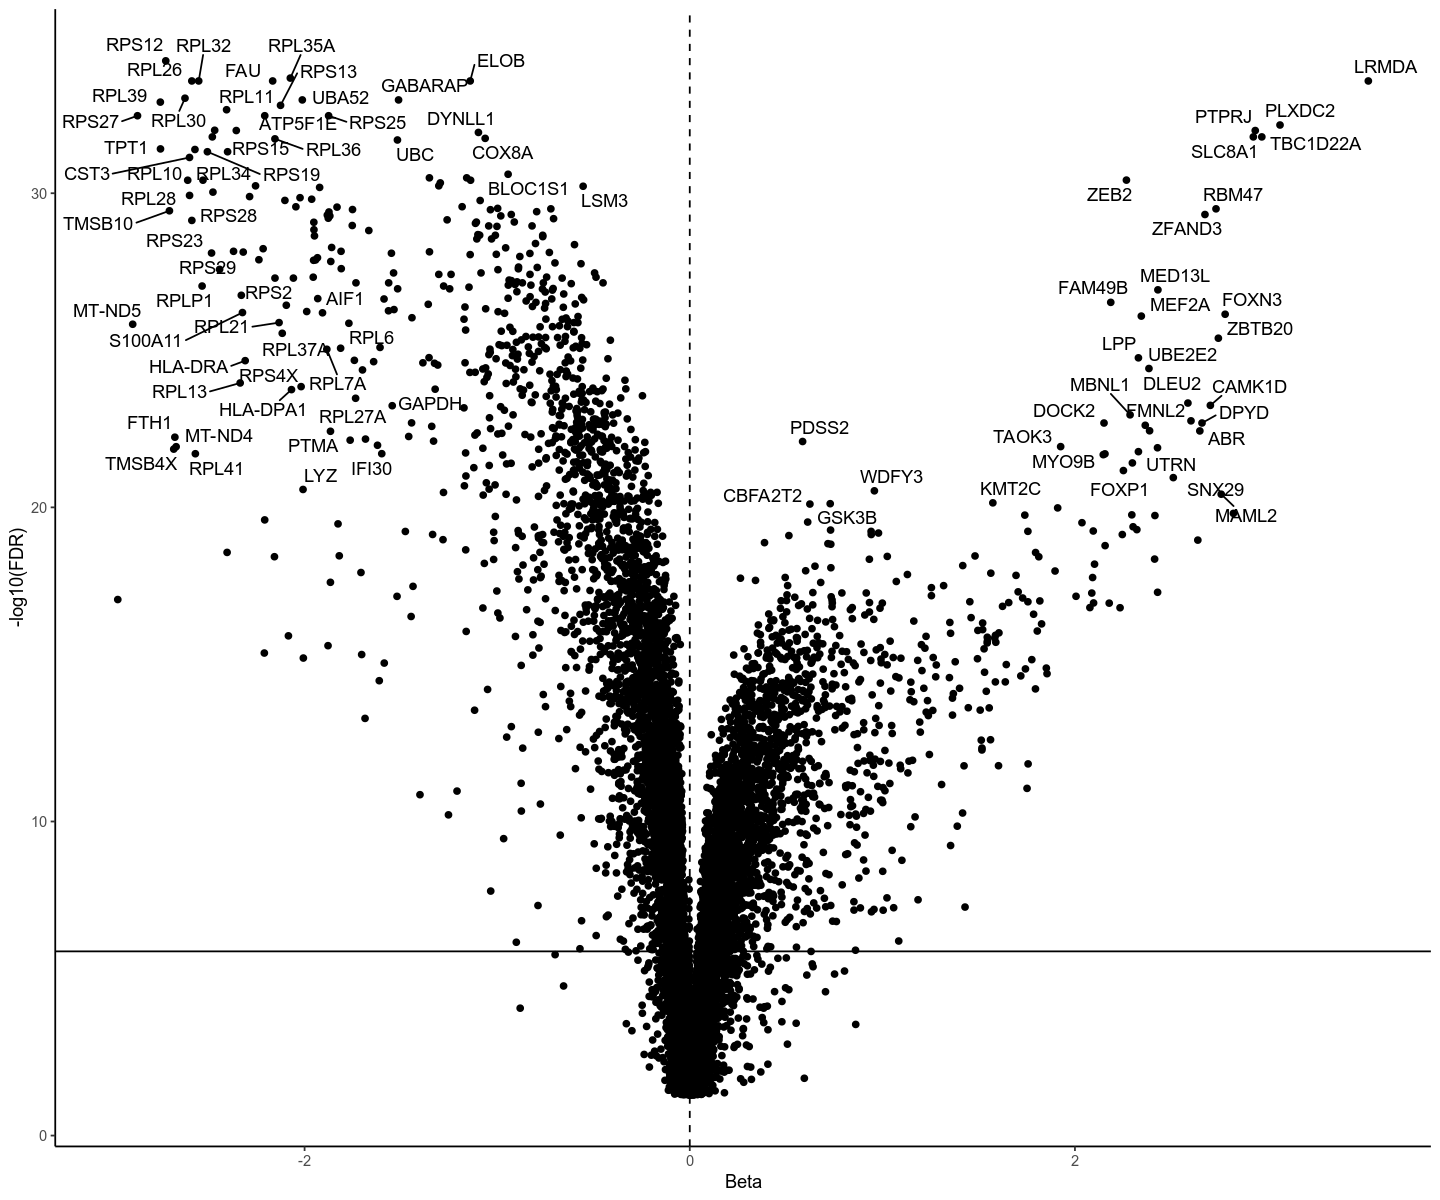

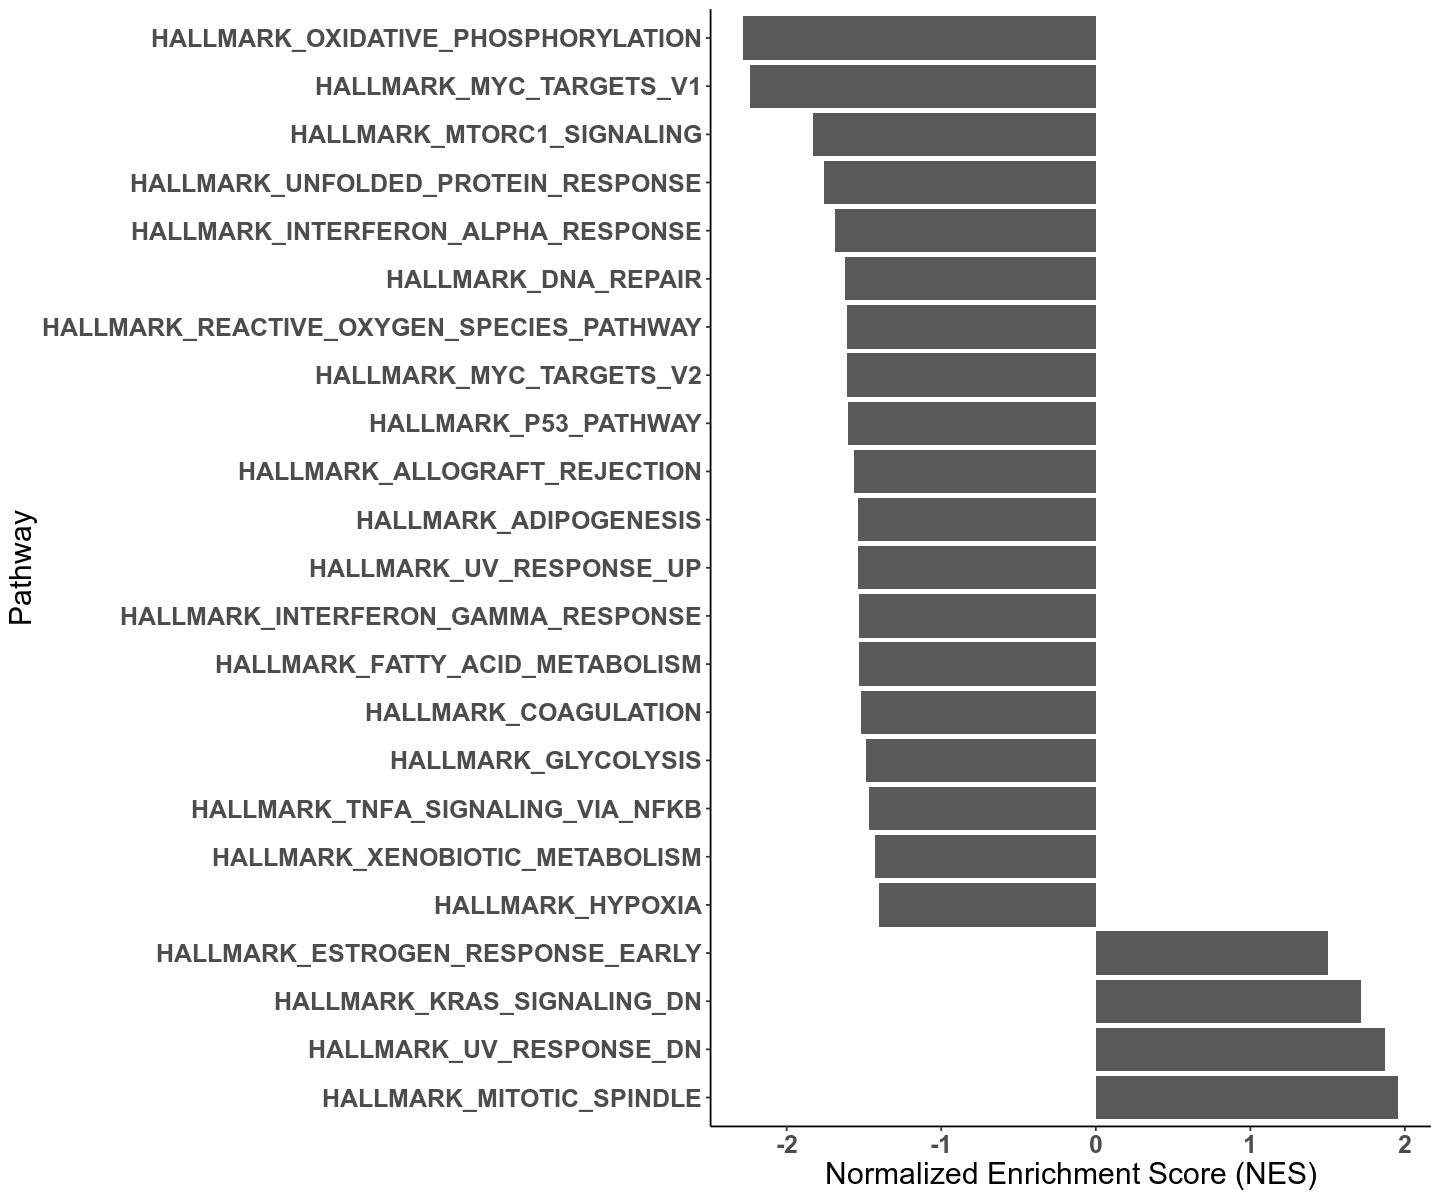

In [325]:
fig.size(10,12)

ggplot(out_filter %>% 
           mutate(label = ifelse(-log10(FDR) > 20, gene, NA)), aes(x = Beta, y = -log10(FDR))) + 
    geom_point() + 
    geom_vline(aes(xintercept = 0), linetype = "dashed") + 
    geom_hline(aes(yintercept = -log10(0.05/36601))) + 
    theme_classic() + 
    ggrepel::geom_text_repel(aes(label = label))


ggplot(gsea.H %>% filter(padj < 0.05), aes(x = NES, y = pathway)) +
    geom_bar(stat = "identity") +
    theme_classic() + 
    scale_y_discrete(limits = gsea.H %>% filter(padj < 0.05) %>% arrange(desc(NES)) %>% pull(pathway)) + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15, face = "bold"),
          axis.title = element_text(size = 18)) +
    labs(x = 'Normalized Enrichment Score (NES)', y = 'Pathway')